# 01 · Data Understanding

**Notebook:** 01 of 04  
**Goal:** Load raw data, validate quality, inspect every column, and produce a clean dataset for bivariate and multivariate analysis.

### What this notebook covers
- Data loading and schema inspection
- Missing values & duplicates
- Column-by-column univariate inspection and cleaning decisions
- Save cleaned DataFrame for the next analysis step

In [72]:
import pandas as pd
import numpy as np
import plotly.express as px

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

# Upload data

In [73]:
df = pd.read_excel('/Users/mohammedmahmood/Desktop/Data projects/Projects/Data science/Supervised /Fresco Retailer Product Return Prediction/data/Fresco_Retailerr.xlsx')

In [74]:
df.sample(5)

,transaction_id,Month,product_category,Product_Subcategory,Qty,Rate,Amount,Tax,Delivery_chrgs,Payment_mode,...,Reviews,CustID,Income,city,Return,DOB,Gender,Marital_status,Education_Level,Profession_Type
15075,49982032355,October,Clothing,Women,5,559,2795,293.475,NaN,Credit Card,...,1.0,5661,98459.0,Ahmedabad,True,1969-02-22,F,1,Graduation,Self Employed
12736,7924645634,September,Electronics,Audio and video,4,1408,5632,591.360,250.0,Debit Card,...,5.0,2971,132727.0,Mumbai,False,1971-08-30,F,0,Basic,Self Employed
13974,85037832041,September,Clothing,Mens,5,1270,6350,666.750,NaN,Credit Card,...,4.0,14528,18776.0,Bangalore,False,1970-05-13,F,1,Graduation,Self Employed
7544,57921017268,May,Footwear,Mens,3,513,1539,161.595,90.0,Mobile Payments,...,5.0,6097,112210.0,Bangalore,False,1977-04-21,F,1,PhD,Others
1129,59570732536,January,Bags,Women,5,868,868,91.140,NaN,Mobile Payments,...,1.0,10656,80172.0,Chennai,True,1984-10-15,M,1,Master,Self Employed


In [75]:
df.columns

Index(['transaction_id', 'Month', 'product_category', 'Product_Subcategory',
       'Qty', 'Rate', 'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'CustID', 'Income', 'city', 'Return', 'DOB',
       'Gender', 'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

In [76]:
# shape of the dataset
df.shape

(19597, 21)

## Some information about data 

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19597 entries, 0 to 19596
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       19597 non-null  int64         
 1   Month                19597 non-null  object        
 2   product_category     19597 non-null  object        
 3   Product_Subcategory  19597 non-null  object        
 4   Qty                  19597 non-null  int64         
 5   Rate                 19597 non-null  int64         
 6   Amount               19597 non-null  int64         
 7   Tax                  19597 non-null  float64       
 8   Delivery_chrgs       10707 non-null  float64       
 9   Payment_mode         19597 non-null  object        
 10  Store_type           19597 non-null  object        
 11  Reviews              19546 non-null  float64       
 12  CustID               19597 non-null  int64         
 13  Income               19554 non-

### All data types are correct, No handling was needed.

# Check Missing values

In [78]:
df.isna().sum() 

transaction_id            0
Month                     0
product_category          0
Product_Subcategory       0
Qty                       0
Rate                      0
Amount                    0
Tax                       0
Delivery_chrgs         8890
Payment_mode              0
Store_type                0
Reviews                  51
CustID                    0
Income                   43
city                      0
Return                    0
DOB                       0
Gender                    0
Marital_status            0
Education_Level           0
Profession_Type           0
dtype: int64

### **Delivery Charges Column**

The column has around 50% missing values. We will check it during univariate analysis to decide whether to drop it or impute the missing values.

In [79]:
# drop unneeded columns in prediction and analysis
df.drop(["CustID", "transaction_id"], inplace= True, axis= 1)

# Check duplicated

In [80]:
df.duplicated().sum()

0

In [81]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Qty', 'Rate',
       'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

# Univariate analysis
### In this step I will go through each column individually to identify and address any issues, and do EDA to gain a deeper understanding of the features.

## Month

In [82]:
# will not include in the modeling but will keep for analysis
df.Month.unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

In [83]:
df.Month.value_counts()

Month
January      1908
October      1829
November     1785
December     1752
May          1747
February     1631
March        1548
September    1514
August       1495
July         1494
April        1471
June         1423
Name: count, dtype: int64

## product_category

In [84]:
df.product_category.unique()

array(['Books', 'Clothing', 'Home and kitchen', 'Footwear', 'Bags',
       'Electronics'], dtype=object)

In [85]:
df.product_category.value_counts()

product_category
Footwear            5027
Clothing            4286
Home and kitchen    3575
Bags                2693
Books               2426
Electronics         1590
Name: count, dtype: int64

## Product_Subcategory

In [86]:
df.Product_Subcategory.unique()

array(['Fiction', 'Women', 'Bath', 'Mens', 'Kitchen', 'Furnishing',
       'Mobiles', 'DIY', 'Kids', 'Non-Fiction', 'Audio and video',
       'Computers', 'Cameras', 'Tools', 'Academic', 'Personal Appliances'],
      dtype=object)

In [87]:
df.Product_Subcategory.value_counts()

Product_Subcategory
Women                  5494
Mens                   4879
Kids                   1633
Furnishing              951
Kitchen                 912
Bath                    859
Tools                   853
DIY                     642
Academic                615
Non-Fiction             596
Fiction                 573
Computers               331
Cameras                 327
Audio and video         326
Mobiles                 305
Personal Appliances     301
Name: count, dtype: int64

## Qty

In [88]:
# rename column to be understandable
df.rename(columns={'Qty': 'Quantity'}, inplace=True)

In [89]:
df.Quantity.unique()

array([3, 5, 4, 2, 1])

In [90]:
df.Quantity.value_counts()

Quantity
5    4599
4    3941
1    3795
3    3637
2    3625
Name: count, dtype: int64

In [91]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity', 'Rate',
       'Amount', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type'],
      dtype='object')

## Rate

In [92]:
df.rename(columns={ 'Rate': 'Unit_Price'}, inplace=True)

In [93]:
df.Unit_Price.describe()

count    19597.000000
mean       777.154718
std        414.308709
min         70.000000
25%        418.000000
50%        775.000000
75%       1136.000000
max       1500.000000
Name: Unit_Price, dtype: float64

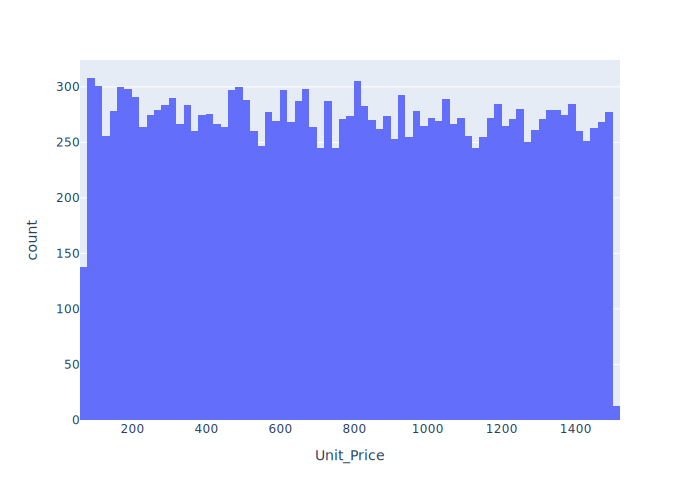

In [94]:
px.histogram(df, x= "Unit_Price" )

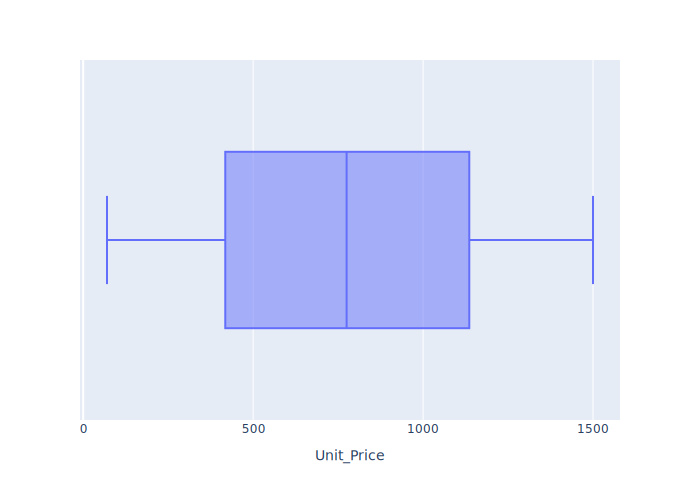

In [95]:
px.box(df, x= "Unit_Price" )

## Amount

In [96]:
df[["Quantity", "Unit_Price", "Amount", "Tax", "Delivery_chrgs" ] ].head(10)

,Quantity,Unit_Price,Amount,Tax,Delivery_chrgs
0,3,359,1795,188.475,90.0
1,5,1129,5645,592.725,250.0
2,4,1327,6635,696.675,NaN
3,5,1325,6625,695.625,NaN
4,3,1237,6185,649.425,NaN
5,5,837,837,87.885,50.0
6,4,931,2793,293.265,NaN
7,2,1211,3633,381.465,200.0
8,1,1497,4491,471.555,200.0
9,5,1008,2016,211.680,90.0


### During data validation, we discovered inconsistencies in the Amount column. For example, in the first row:

**Quantity = 3**
**Unit_Price = 359**
**Expected Amount = 3 × 359 = 1077**

**However, the existing value in the Amount column was 1795, which is incorrect.**

**To resolve this issue and ensure data accuracy, we recalculated the Amount BY multibly Quantity * Unit_Price  deleted the original and named by Total_Price**

In [97]:
# drop column
df.drop("Amount", axis= 1, inplace= True)

In [98]:
# recalculated column and named by Total_Price
df['Price'] = df['Quantity'] * df['Unit_Price']

In [99]:
df.Price.describe()

count    19597.000000
mean      2397.469664
std       1795.267407
min         70.000000
25%        948.000000
50%       1936.000000
75%       3534.000000
max       7500.000000
Name: Price, dtype: float64

In [100]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Tax', 'Delivery_chrgs', 'Payment_mode', 'Store_type',
       'Reviews', 'Income', 'city', 'Return', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Price'],
      dtype='object')

In [101]:
# Rearrange columns
df = df[['Month', 'product_category', 'Product_Subcategory', 'Quantity',
         'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs' ,'Payment_mode', 'Store_type', 'Reviews',
         'Income', 'city', 'DOB', 'Gender', 'Marital_status', 'Education_Level',
         'Profession_Type', 'Return']]

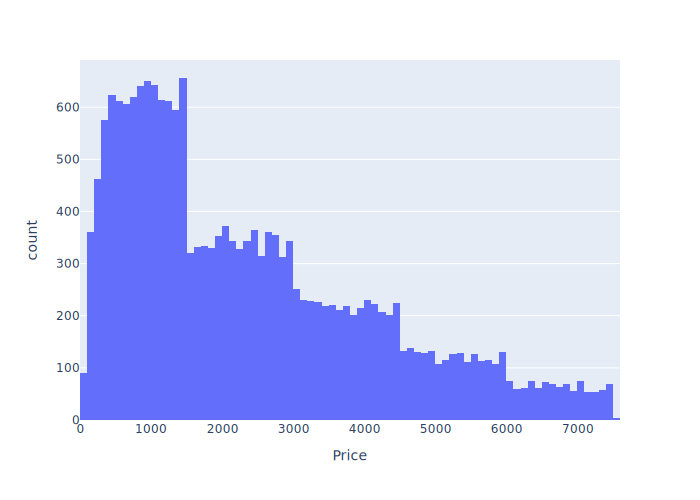

In [102]:
px.histogram(df, x= "Price" )

In [103]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'Income', 'city', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Return'],
      dtype='object')

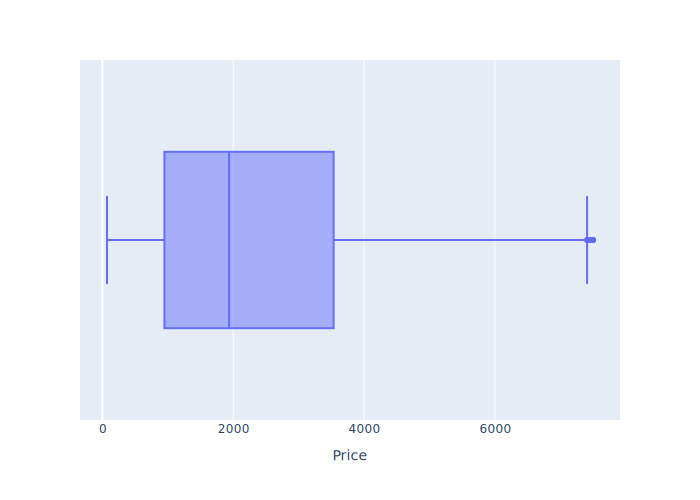

In [104]:
px.box(df, x= "Price" )

In [105]:
from datasist.structdata import detect_outliers

outliers_indices = detect_outliers(df, 0 , ["Price"])

len(outliers_indices)

62

### Tax

In [106]:
df.Tax.describe()

count    19597.000000
mean       241.722141
std        182.975767
min          7.350000
25%         96.075000
50%        191.730000
75%        351.540000
max        787.500000
Name: Tax, dtype: float64

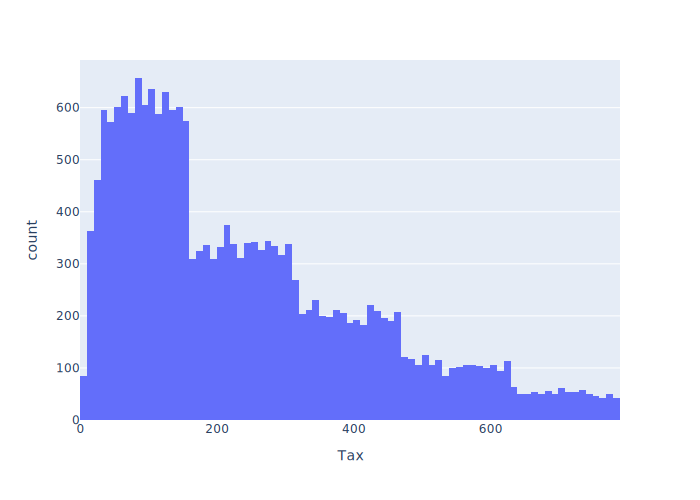

In [107]:
px.histogram(df, x= "Tax" )

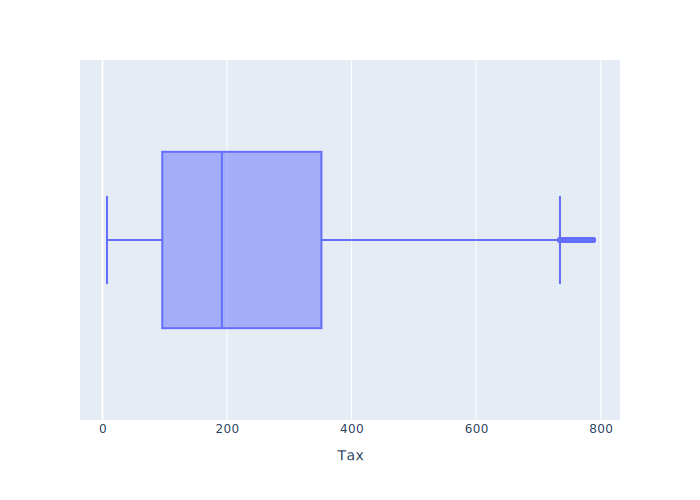

In [108]:
px.box(df, x= "Tax" )

In [109]:
from datasist.structdata import detect_outliers

outliers_indices = detect_outliers(df, 0 , ["Tax"])

len(outliers_indices)

265

In [110]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Delivery_chrgs', 'Payment_mode',
       'Store_type', 'Reviews', 'Income', 'city', 'DOB', 'Gender',
       'Marital_status', 'Education_Level', 'Profession_Type', 'Return'],
      dtype='object')

## Delivery_charges 
#### (will drop column becouse has very big number of missing vlues and can't imputed )

In [111]:
df.Delivery_chrgs.isna().sum()

8890

In [112]:
df.drop("Delivery_chrgs", inplace= True, axis= 1)
df.reset_index(inplace= True, drop= True)

### Payment_mode

In [113]:
df.Payment_mode.unique()

array(['Mobile Payments', 'Credit Card', 'Debit Card', 'Cash'],
      dtype=object)

In [114]:
df.Payment_mode.value_counts()

Payment_mode
Mobile Payments    8191
Credit Card        4683
Debit Card         4677
Cash               2046
Name: count, dtype: int64

## Store_type

In [115]:
df.Store_type.unique()

array(['e-Shop', 'TeleShop', 'MBR', 'Flagship store'], dtype=object)

In [116]:
df.Store_type.value_counts()

Store_type
e-Shop            8014
MBR               3886
TeleShop          3872
Flagship store    3825
Name: count, dtype: int64

## Reviews

In [117]:
df.Reviews.unique()

array([ 1.,  4.,  2.,  5.,  3., nan])

In [118]:
df.Reviews.value_counts()

Reviews
5.0    9537
4.0    4696
1.0    2491
2.0    1542
3.0    1280
Name: count, dtype: int64

In [119]:
df['Reviews'].isnull().sum()

51

In [120]:
# remave nulll in column because it dosn't make sense to impute Reviews
df = df.dropna(subset=['Reviews'])
df['Reviews'].isnull().sum()

0

In [121]:
df["Reviews"].value_counts()

Reviews
5.0    9537
4.0    4696
1.0    2491
2.0    1542
3.0    1280
Name: count, dtype: int64

In [122]:
df.columns

Index(['Month', 'product_category', 'Product_Subcategory', 'Quantity',
       'Unit_Price', 'Price', 'Tax', 'Payment_mode', 'Store_type', 'Reviews',
       'Income', 'city', 'DOB', 'Gender', 'Marital_status', 'Education_Level',
       'Profession_Type', 'Return'],
      dtype='object')

## Income

In [123]:
df.Income.describe()

count     19504.000000
mean      70516.888074
std       37418.384648
min        7157.000000
25%       37950.000000
50%       69293.000000
75%       99534.000000
max      159984.000000
Name: Income, dtype: float64

In [124]:
df['Income'].isnull().sum()

42

In [125]:
df = df.dropna(subset=['Income'])
df['Income'].isnull().sum()

0

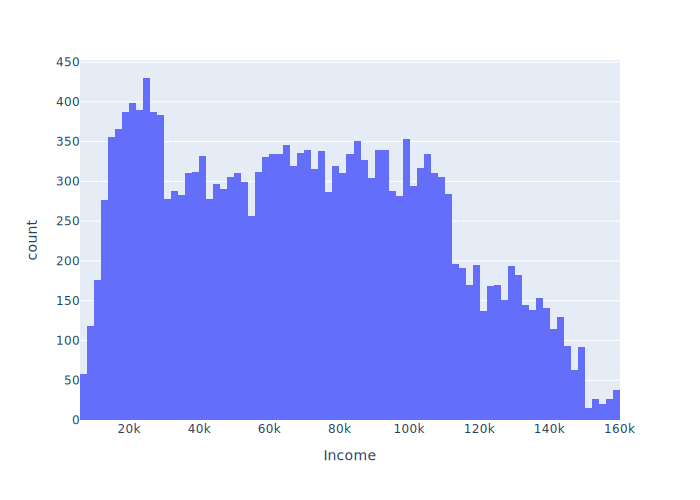

In [126]:
px.histogram(df, x= "Income" )

## Return

In [127]:
df.Return.unique()

array([ True, False])

In [128]:
df.Return.value_counts()

Return
False    17457
True      2047
Name: count, dtype: int64

In [129]:
df["Return"] = df["Return"].map({False: 0, True: 1})

In [130]:
df.Return.value_counts()

Return
0    17457
1     2047
Name: count, dtype: int64

### **Target is imbalanced and will be handled in the preprocessing pipeline.**

## DOB

In [131]:
df.DOB.unique()

<DatetimeArray>
['1985-12-31 00:00:00', '1985-12-29 00:00:00', '1985-12-27 00:00:00',
 '1985-12-26 00:00:00', '1985-12-24 00:00:00', '1985-12-22 00:00:00',
 '1985-12-20 00:00:00', '1985-12-19 00:00:00', '1985-12-18 00:00:00',
 '1985-12-17 00:00:00',
 ...
 '1964-01-29 00:00:00', '1964-01-28 00:00:00', '1964-01-22 00:00:00',
 '1964-01-11 00:00:00', '1964-01-10 00:00:00', '1964-01-06 00:00:00',
 '1964-01-05 00:00:00', '1964-01-04 00:00:00', '1964-01-03 00:00:00',
 '1964-01-02 00:00:00']
Length: 3996, dtype: datetime64[ns]

In [132]:
# I deleted the column because it will not important in prediction.
df.drop("DOB", inplace= True, axis= 1 )
df.reset_index(inplace= True, drop= True)

## Gender

In [133]:
df.Gender.unique()

array(['M', 'F'], dtype=object)

In [134]:
df.Gender.value_counts()

Gender
M    12028
F     7476
Name: count, dtype: int64

## Marital_status

In [135]:
df.Marital_status.unique()

array([0, 1])

In [136]:
df.Marital_status.value_counts()

Marital_status
1    10316
0     9188
Name: count, dtype: int64

## Education_Level

In [137]:
df.Education_Level.unique()

array(['PhD', 'Master', 'Basic', 'Others', 'Graduation'], dtype=object)

In [138]:
df.Education_Level.value_counts()

Education_Level
Others        4111
Graduation    3993
Master        3920
Basic         3885
PhD           3595
Name: count, dtype: int64

## Profession_Type

In [139]:
df.Profession_Type.unique()

array(['Others', 'Salaried', 'Self Employed'], dtype=object)

In [143]:
df.drop_duplicates(inplace= True)
df.reset_index(inplace= True, drop= True)

In [144]:
# ── Save cleaned data for notebook 02 ────────────────────────────────────────
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/01_cleaned.csv", index=False)
print(f"Saved cleaned data → data/01_cleaned.csv  |  shape: {df.shape}")

Saved cleaned data → data/01_cleaned.csv  |  shape: (19504, 17)
